In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
minist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = minist.load_data()

In [3]:
x_train, x_test = x_train / 255.0, x_test / 255.0

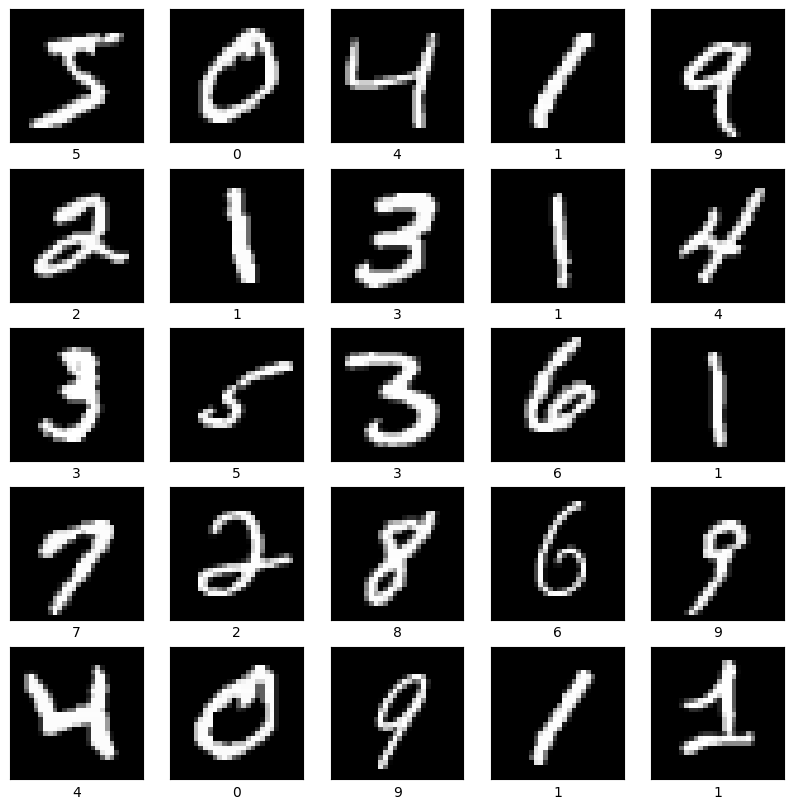

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap='gray')
    plt.xlabel(str(y_train[i]))
plt.show()

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(16, 3, activation='relu'),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


#### Conv2D(16, 3 or (3,3), padding='valid', input_shape=(28, 28, 1), activation='relu')
- 첫번째 인자 : 컨볼루션 필터의 수
- 두번째 인자 : 컨볼루션 커널의 (행, 열) 크기
- padding : 경계 처리 방법 정의.
    - 'valid' : 유효한 영역만 출력.출력 이미지 사이즈는 입력 사이즈보다 작아진다.
    - 'same' : 출력 이미지 사이즈가 입력 이미지 사이즈와 동일하다.
- input_shape : 샘플 수를 제외한 입력 형태 정의. 모델에서 첫 레이어일 때만 정의한다.
    - (행, 열, 채널 수)로 정의한다. 흑백영상인 경우에는 채널이 1이고, 컬러(RGB)영상인 경우에는 채널을 3으로 설정한다.
- activation : 활성화 함수를 설정한다.
    - 'linear' : 입력뉴런과 가중치로 계산된 결과값이 그대로 출력으로 나온다.default=None
    - 'relu' : rectifier 함수, 은익층에 주로 쓰인다.
    - 'sigmoid' : 시그모이드 함수, 이진 분류 문제에서 출력층에 주로 쓰인다.
    - 'softmax' : 소프트맥스 함수, 다중 클래스 분류 문제에서 출력층에 주로 쓰인다.

In [7]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


1875/1875 [==============================] - 11s 5ms/step - loss: 0.1445 - accuracy: 0.9571
Epoch 2/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0464 - accuracy: 0.9855
Epoch 3/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0245 - accuracy: 0.9920
Epoch 4/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0139 - accuracy: 0.9955
Epoch 5/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0094 - accuracy: 0.9973


In [8]:
model.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - loss: 0.0671 - accuracy: 0.9835 - 576ms/epoch - 2ms/step


[0.06706679612398148, 0.9835000038146973]

In [9]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 flatten_2 (Flatten)         (None, 10816)             0         
                                                                 
 dense_2 (Dense)             (None, 128)               1384576   
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1386026 (5.29 MB)
Trainable params: 1386026 (5.29 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
inputs = keras.Input(shape=(28, 28))
x = layers.Reshape((28, 28, 1))(inputs)
x = layers.Conv2D(16, 3, activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(128)(x)
x = layers.Dense(10, activation='softmax')(x)
outputs = x
model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 reshape (Reshape)           (None, 28, 28, 1)         0         
                                                                 
 conv2d_2 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 flatten_3 (Flatten)         (None, 10816)             0         
                                                                 
 dense_4 (Dense)             (None, 128)               1384576   
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1386026 (5.29 MB)
Trainable params: 1386026 (5.

In [ ]:
model = keras.Sequential()

